###CHANNEL GAIN CODE - OUTDOOR

In [35]:
import numpy as np
import math

c = 3 * 10**8                                    # propagation velocity in the free space [m/s]
h_BS = 3.5                                       # antenna height of the base station [m]
h_UT = 3.5                                       # antenna height of the user terminal [m]
h_E = 1                                          # effective environment height [m]
h_prime_BS = h_BS - h_E                          # effective antenna height of the base station [m]
h_prime_UT = h_UT - h_E                          # effective antenna height of the user terminal [m]

def get_distance2D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
    return d

def get_distance3D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2)
    return d

def get_PL_LOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    d_BP = (4 * h_prime_BS * h_prime_UT * f_c) / c
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= d_BP):
            PL_LOS = 32.4 + 21*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
        elif (d_2D >= d_BP) and (d_2D <= 5 * 10**3):
            PL_LOS = 32.4 + 40*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9)) - 9.5*math.log10((d_BP)**2 + (p1[2] - p2[2])**2)
    return PL_LOS

def get_PL_NLOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_prime_NLOS = 17.3 + 38.3*math.log10(d_3D) + 24.9*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= 5 * 10**3):
            PL_prime_NLOS = 22.4 + 35.3*math.log10(d_3D) + 21.3*math.log10(f_c * 10**(-9)) - 0.3*(p2[2] - 1.5)
    PL_NLOS = max(get_PL_LOS(p1, p2, f_c), PL_prime_NLOS)
    return PL_NLOS

#this function gives the probability that how much of the transmission is in Line of Sight
def get_Pr(p1, p2):
    d_2D = get_distance2D(p1, p2)
    if (d_2D < 10):
        if (d_2D <= 1.2):
            pr_LOS = 1
        elif (d_2D > 1.2) and (d_2D < 6.5):
            pr_LOS = math.exp(-(d_2D - 1.2)/4.7)
        elif (d_2D >= 6.5):
            pr_LOS = math.exp(-(d_2D - 6.5)/32.6) * 0.32
    else:
        if d_2D <= 18:
            pr_LOS = 1
        elif d_2D > 18:
            pr_LOS = (18/d_2D) + (math.exp(-d_2D/36) * (1 - (18/d_2D)))
    return pr_LOS

def get_PL(p1, p2, f_c):
    PL = get_Pr(p1, p2) * get_PL_LOS(p1, p2, f_c) + (1 - get_Pr(p1, p2)) * get_PL_NLOS(p1, p2, f_c)
    return PL

def get_channel_gain(p1, p2, f_c):
    g = 1 / 10**(get_PL(p1, p2, f_c) / 10)
    return g

###CHANNEL GAIN CODE - INHOUSE(OPEN/MIXED)

In [36]:
import numpy as np
import math

def get_distance2D(p1, p2):
    return np.hypot(p1[0]-p2[0], p1[1]-p2[1])

def get_distance3D(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# -------- 38.901 InH (Indoor-Office) PATH LOSS --------
def get_PL_LOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office LOS:
      PL_LOS = 32.4 + 17.3*log10(d_3D) + 20*log10(fc_GHz), for 1 m <= d_3D <= 150 m
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:  # spec validity starts at 1 m
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20.0*math.log10(fc_GHz)
    return PL_LOS

def get_PL_NLOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office NLOS (use max with LOS):
      PL'_NLOS = 38.3*log10(d_3D) + 17.30*log10(fc_GHz) + 24.9, for 1 m <= d_3D <= 150 m
      PL_NLOS = max(PL_LOS, PL'_NLOS)
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = get_PL_LOS_InH(p1, p2, f_c)
    PLp_NLOS = 38.3*math.log10(d_3D) + 17.30*math.log10(fc_GHz) + 24.9
    return max(PL_LOS, PLp_NLOS)

# -------- LOS PROBABILITY (choose 'open' or 'mixed') --------
def get_Pr_InH(p1, p2, office_type='open'):
    """
    InH LOS probability from TR 38.901 Table 7.4.2-1.
    office_type: 'open' (default) or 'mixed'
    Uses d_in-2D (horizontal) in meters.
    """
    d = get_distance2D(p1, p2)
    if office_type == 'mixed':
        if d <= 1.2:
            return 1.0
        elif d < 6.5:
            return math.exp(-(d - 1.2)/4.7)
        else:
            return 0.32 * math.exp(-(d - 6.5)/32.6)
    else:  # 'open' office
        if d <= 5.0:
            return 1.0
        elif d < 49.0:
            return math.exp(-(d - 5.0)/70.0)
        else:
            return 0.54 * math.exp(-(d - 49.0)/211.7)

def get_PL_InH(p1, p2, f_c, office_type='open'):
    pr = get_Pr_InH(p1, p2, office_type)
    PL_los = get_PL_LOS_InH(p1, p2, f_c)
    PL_nlos = get_PL_NLOS_InH(p1, p2, f_c)
    return pr*PL_los + (1.0 - pr)*PL_nlos

def get_channel_gain_InH(p1, p2, f_c, office_type='open'):
    """
    Returns linear power gain g = 10^(-PL/10)
    """
    PL = get_PL_InH(p1, p2, f_c, office_type)
    return 10.0**(-PL/10.0)


###NON EXHAUSTIVE C BOUND

In [37]:
import numpy as np

def compute_c_bounds(h, P_max, eta):
    N = len(h)

    print("For number of transmitters: ",N)
    c_lower = 0
    for n in range(N):
        sum1 = np.sum(h * np.sqrt(P_max) / np.sqrt(eta))
        me = h[n] * np.sqrt(P_max[n]) / np.sqrt(eta)
        other = sum1 - me
        c_low = (np.sqrt(eta) / (2 * np.sqrt(P_max[n]) * np.abs(h[n]))) * np.exp(other)

        c_lower = max(c_lower, c_low)

    return c_lower

###EXHAUSTIVE C BOUND

In [38]:
import numpy as np
import itertools

def compute_c_bounds_exhaustive(h, P_max, eta, step=0.1):
    """
    Compute c bounds by exhaustively searching all combinations of power values.
    We create for step=0.1 all combinations of P values between 0 and P_max. And for all of them calculate lower bound of c.
    We take max of lower bounds
    for N=100 it it 10^100 combinations so actually it is better ro aproximate using P_max
    """
    N = len(h)

    # Create power value ranges for each user
    power_ranges = []
    for i in range(N):
        # Generate power values from step to P_max[i] with step size
        power_values = np.arange(step, P_max[i] + step, step)
        power_ranges.append(power_values)

    c_lower = 0
    total_combinations = 1
    for i in range(N):
        total_combinations *= len(power_ranges[i])

    print(f"Total combinations to check: {total_combinations}")

    # Use itertools.product to generate all combinations
    for P_curr in itertools.product(*power_ranges):
        P_curr = np.array(P_curr)

        # Calculate the sum for this combination
        sum_val = np.sum(h * np.sqrt(P_curr) / np.sqrt(eta))

        # Calculate lower bound for each user
        for n in range(N):
            me = h[n] * np.sqrt(P_curr[n]) / np.sqrt(eta)
            other = sum_val - me
            low = (np.sqrt(eta) / (2 * np.sqrt(P_max[n]) * np.abs(h[n]))) * np.exp(other)
            c_lower = max(c_lower, low)

    return c_lower

###PLOT TO SEE RECEIVER TRANSMITTERS ARRANGEMENT

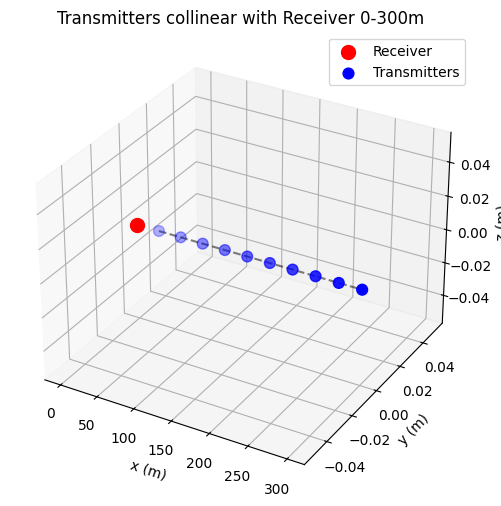

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N = 10
d_max = 300.0
max_iteration = 10
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]


# ---- Plot 3D ----
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# Receiver
ax.scatter(*receiver_coordinates, c='red', s=100, label='Receiver')

# Transmitters
tx = np.array(transmitter_coordinates)
ax.scatter(tx[:,0], tx[:,1], tx[:,2], c='blue', s=60, label='Transmitters')

# Connect them along the line
ax.plot(tx[:,0], tx[:,1], tx[:,2], 'k--', alpha=0.5)

# Labels
ax.set_title("Transmitters collinear with Receiver 0-300m")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.legend()
ax.grid(True)

plt.show()


###TESTING C BOUND

In [40]:
"""N = 10
max_iteration = 50
receiver_coordinates = (0, 0, 0)
transmitter_coordinates = [(7.5 + i*4.5, 3.0 + i*2.25, 2.25 + i*0.75) for i in range(N)]"""

d_max = 300.0
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

#h contains channel gains for both the 5 nodes
h = [0 for i in range(N)]
for i in range(N):
    h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)              # current powers
P_max = np.ones(N)                       # max power = 1 for all
eta = 1.0

c_lower = compute_c_bounds(h, P_max, eta)
print(c_lower)

For number of transmitters:  10
251897735346.7284


###UTILITY AND OPTIMAL POWER FUNCTIONS

In [41]:
import numpy as np
import numpy.typing as npt

def utility_vector(P: npt.NDArray[np.float64], h: npt.NDArray[np.float64], c: np.float64, eta: np.float64):
    utilities = np.zeros(len(P))
    sum1 = np.sum(h * np.sqrt(P) / np.sqrt(eta))

    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        utilities[i] = me * np.exp(other) - c * np.power(me, 2)
    return utilities


def closed_form_p_star(h: npt.NDArray[np.float64], c: np.float64, eta: np.float64, P_max: npt.NDArray[np.float64], P: npt.NDArray[np.float64]):
    sum1 = np.sum(h * np.sqrt(P)/np.sqrt(eta))
    P_star = np.zeros(len(P))
    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        P_star[i] = eta * np.exp(2*other)/ (4 * np.power(c, 2) * np.power(h[i], 2))

    P_star = np.clip(P_star, 0, P_max)
    return P_star

###ADAPTIVE BEST RESPONSE FUNCTION

In [42]:
#Adaptive Best Response Function
import time
import numpy as np
import numpy.typing as npt
import pandas as pd

def adaptive_best_response(
    h: npt.NDArray[np.float64],
    eta: np.float64,
    epsilon: np.float64,
    P_max: npt.NDArray[np.float64],
    max_iteration: int = 1000
):
    print('Executing adaptive best response')
    # Compute feasible bounds for c
    #c = compute_c_bounds(h,P_max, eta)
    c = 200000000003.03387


    history_util = {}
    history_power = {}

    P_current = np.random.uniform(0, P_max, len(h))
    utility_history = [utility_vector(P_current, h, c, eta)]
    power_history = [P_current.copy()]
    convergence = 0
    iteration = 0
    stop_due_to_negative = False
    stop_due_to_max = False

    # Start timing BRD iterations
    brd_start = time.time()

    while convergence == 0:
        iteration += 1

        P_new = closed_form_p_star(h, c, eta, P_max, P_current)
        utility_history.append(utility_vector(P_new, h, c, eta))
        power_history.append(P_new.copy())

        if np.any(utility_history[-1] < 0):
            stop_due_to_negative = True
            break

        if np.all(P_new == P_max):
            stop_due_to_max = True
            break

        if iteration == max_iteration or np.all(np.abs(utility_history[-1] - utility_history[-2]) < epsilon):
            convergence = 1
        else:
            P_current = P_new

    # End timing
    brd_time = time.time() - brd_start

    history_util[c] = np.array(utility_history)
    history_power[c] = np.array(power_history)

    if not stop_due_to_negative and not stop_due_to_max:
        df = pd.DataFrame({
            "Node": np.arange(1, len(P) + 1),
            "Final Power P*": P_new,
            "Final Utility": utility_history[-1],
            "Channel Gain h": h
        })
        return c, history_util, history_power, df, brd_time

In [43]:
epsilon = np.float64(1e-30)
c_star, utility_histories, power_histories, df,brd_time = adaptive_best_response(
        h, eta, epsilon, P_max, max_iteration
    )

if c_star is not None:
        print("\n" + "="*80)
        print("FINAL RESULTS SUMMARY")
        print("="*80)
        pd.set_option('display.float_format', '{:.6e}'.format)
        print(df.to_string(index=False))
        print("="*80)

Executing adaptive best response

FINAL RESULTS SUMMARY
 Node  Final Power P*  Final Utility  Channel Gain h
    1    3.549147e-09   1.250000e-12    4.196411e-08
    2    1.342309e-06   1.250000e-12    2.157813e-09
    3    6.062187e-05   1.250000e-12    3.210889e-10
    4    8.369814e-04   1.250000e-12    8.641360e-11
    5    5.793018e-03   1.250000e-12    3.284638e-11
    6    2.627874e-02   1.250000e-12    1.542189e-11
    7    9.207133e-02   1.250000e-12    8.239062e-12
    8    2.727483e-01   1.250000e-12    4.786951e-12
    9    6.956548e-01   1.250000e-12    2.997389e-12
   10    1.000000e+00   1.196941e-12    1.984933e-12


###PLOT 1 - BR ITERATIONS VS POWER

In [44]:
power_histories[c_star]

array([[6.6902625782110847e-01, 3.9375932055208263e-01, 6.8311665869216709e-01, 5.9220184825125277e-01, 6.8761969793214461e-01, 8.7184526637139081e-01, 4.6962661532871697e-01,
        9.9338511661452145e-01, 1.7445353219050397e-01, 6.1402395628302153e-01],
       [3.5491466325544474e-09, 1.3423093193471502e-06, 6.0621870542915411e-05, 8.3698148908301756e-04, 5.7930186884624932e-03, 2.6278745010116455e-02, 9.2071341411969043e-02,
        2.7274827921753975e-01, 6.9565484981733439e-01, 1.0000000000000000e+00],
       [3.5491466203539627e-09, 1.3423092262206992e-06, 6.0621866205112169e-05, 8.3698142885981028e-04, 5.7930182711833696e-03, 2.6278743116547525e-02, 9.2071334775967559e-02,
        2.7274825955885001e-01, 6.9565479967220289e-01, 1.0000000000000000e+00],
       [3.5491466203539627e-09, 1.3423092262206992e-06, 6.0621866205112169e-05, 8.3698142885981028e-04, 5.7930182711833696e-03, 2.6278743116547525e-02, 9.2071334775967559e-02,
        2.7274825955885001e-01, 6.9565479967220289e-0

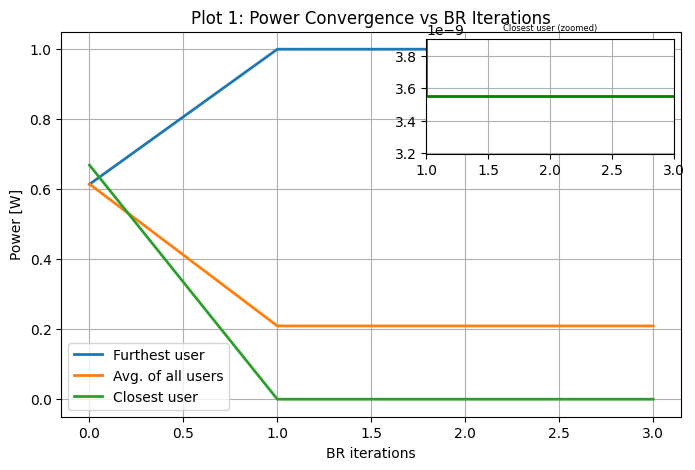

In [45]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

if df is not None:
    power_history = power_histories[c_star]  # shape = (iterations, N)
    closest_idx = np.argmax(h)
    furthest_idx = np.argmin(h)

    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)
    iterations = np.arange(0, power_history.shape[0])

    # Main plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    ax.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    ax.plot(iterations, closest_user, label="Closest user", linewidth=2)

    ax.set_xlabel("BR iterations")
    ax.set_ylabel("Power [W]")
    ax.set_title("Plot 1: Power Convergence vs BR Iterations")
    ax.legend()
    ax.grid(True)

    # Inset focusing on the 'flat' part of closest user (iterations 2 → 4)
    axins = inset_axes(ax, width="40%", height="30%", loc="upper right")  # moved here
    axins.plot(iterations, closest_user, color="green", linewidth=2)
    axins.set_title("Closest user (zoomed)", fontsize=6)

    # Zoom on iterations 2–4 and y-range around the small values
    axins.set_xlim(1, 3)
    axins.set_ylim(min(closest_user[1:]) * 0.9, max(closest_user[1:]) * 1.1)
    axins.grid(True)

    plt.show()


/tmp/ipython-input-3136590927.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


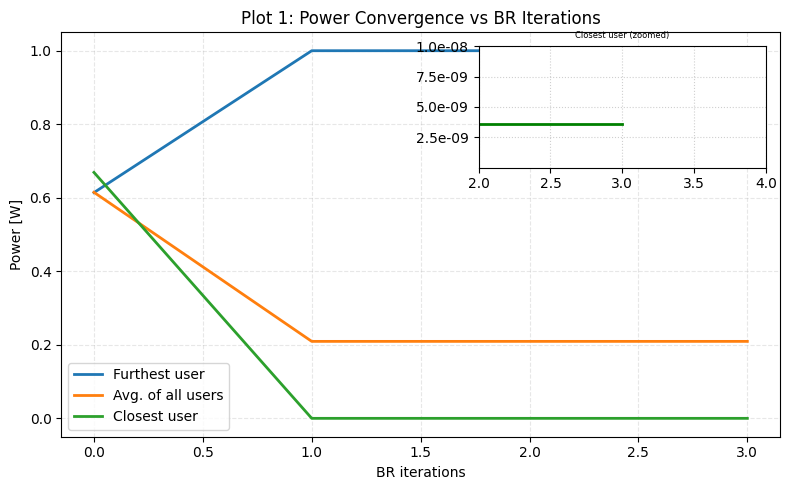

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FormatStrFormatter

if df is not None:
    power_history = power_histories[c_star]  # shape = (iterations, N)
    closest_idx = np.argmax(h)
    furthest_idx = np.argmin(h)

    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)
    iterations = np.arange(0, power_history.shape[0])

    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    ax.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    ax.plot(iterations, closest_user, label="Closest user", linewidth=2)

    ax.set_xlabel("BR iterations")
    ax.set_ylabel("Power [W]")
    ax.set_title("Plot 1: Power Convergence vs BR Iterations")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    # --- Inset focusing on the 'flat' part of closest user (iterations 2 → 4) ---
    axins = inset_axes(ax, width="40%", height="30%", loc="upper right", borderpad=1.0)
    axins.plot(iterations, closest_user, color="green", linewidth=2)

    # Lock the view to your requested ranges
    axins.set_xlim(2, 4)
    axins.set_ylim(1e-15, 1e-8)

    # Scientific notation for tiny values
    axins.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))

    axins.set_title("Closest user (zoomed)", fontsize=6)
    axins.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


###PLOT 2- BR ITERATIONS VS UTILITY

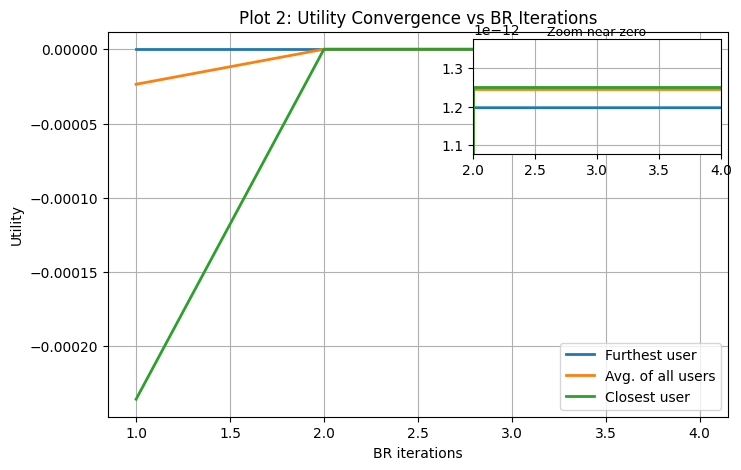

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Pick the utility history for the chosen c
util_history = utility_histories[c_star]  # shape = (iterations, N)

closest_idx = np.argmax(h)
furthest_idx = np.argmin(h)

closest_util = util_history[:, closest_idx]
furthest_util = util_history[:, furthest_idx]
avg_util = np.mean(util_history, axis=1)

iterations = np.arange(1, util_history.shape[0] + 1)

# Main plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, furthest_util, label="Furthest user", linewidth=2)
ax.plot(iterations, avg_util, label="Avg. of all users", linewidth=2)
ax.plot(iterations, closest_util, label="Closest user", linewidth=2)

ax.set_xlabel("BR iterations")
ax.set_ylabel("Utility")
ax.set_title("Plot 2: Utility Convergence vs BR Iterations")
ax.legend()
ax.grid(True)

# Inset: zoom only on the flat region (iterations 2 → 4)
axins = inset_axes(ax, width="40%", height="30%", loc="upper right")
axins.plot(iterations, furthest_util, linewidth=2)
axins.plot(iterations, avg_util, linewidth=2)
axins.plot(iterations, closest_util, linewidth=2)
axins.set_title("Zoom near zero", fontsize=9, pad=2)

# Focus on iterations 2–4
axins.set_xlim(2, 4)

# Tighten y-limits just for this region
flat_values = np.concatenate([
    furthest_util[1:],  # from iteration 2
    avg_util[1:],
    closest_util[1:]
])
axins.set_ylim(min(flat_values) * 0.9, max(flat_values) * 1.1)
axins.grid(True)

plt.show()


###PLOT 3- OPTIMAL POWER ALLOCATION PER USER

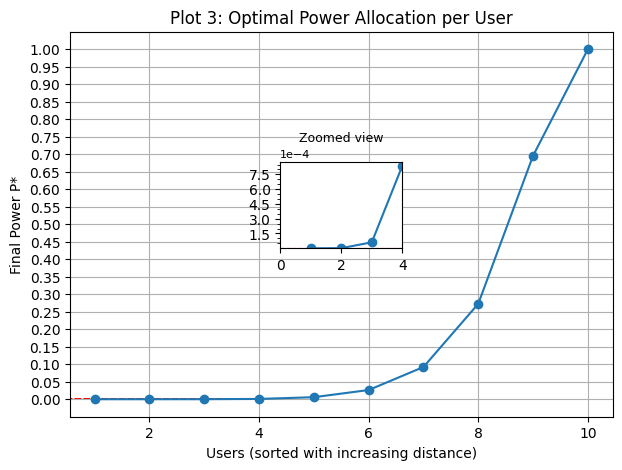

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# Example: assuming df is already defined
users = range(1, len(df) + 1)
power = df["Final Power P*"].values

plt.figure(figsize=(7,5))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted with increasing distance)")
plt.ylabel("Final Power P*")
plt.title("Plot 3: Optimal Power Allocation per User")
plt.grid(True)

# Set y-axis ticks at intervals of 0.05
y_min, y_max = 0, 1.05
plt.yticks(np.arange(y_min, y_max, 0.05))

# --- Inset zoom ---
ax = plt.gca()
axins = inset_axes(
    ax, width="45%", height="45%",
    bbox_to_anchor=(0.25, 0.3, 0.5, 0.5),
    bbox_transform=ax.transAxes, loc="center"
)

axins.plot(users, power, marker='o')

# Focus zoom on users 0 → 4
axins.set_xlim(0, 4)

# Tight y-range based on first 4 users
pmin, pmax = min(power[:4]), max(power[:4])
axins.set_ylim(pmin * 0.95, pmax * 1.05)

# Add horizontal line at 0 for reference
axins.axhline(0, color="red", linestyle="--", linewidth=0.8)

# Force y-axis scientific notation (1e-6)
axins.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axins.yaxis.get_offset_text().set_size(8)   # smaller font for "1e-6"

# Increase resolution of y-axis
axins.yaxis.set_major_locator(plt.MaxNLocator(6))
axins.yaxis.set_minor_locator(plt.MaxNLocator(20))

axins.set_title("Zoomed view", fontsize=9)

# Highlight region in main plot (optional red box)
rect = Rectangle((0, pmin * 0.95),
                 4, (pmax * 1.05) - (pmin * 0.95),
                 linewidth=1.2, edgecolor='red', linestyle='--', fill=False)
ax.add_patch(rect)

plt.show()


###PLOT 4: FINAL UTILITY PER USER

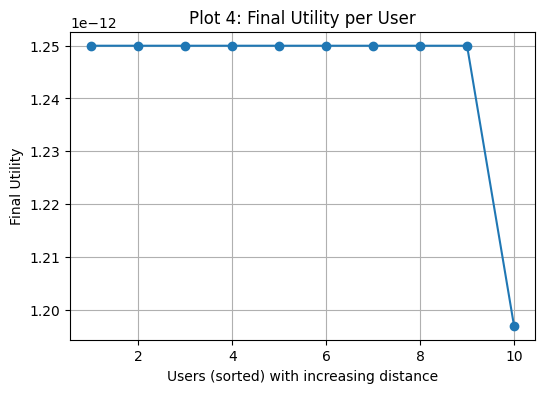

In [49]:
import matplotlib.pyplot as plt

# Sort users by index (or by distance if you have that column)
users = range(1, len(df) + 1)
power = df["Final Utility"].values

plt.figure(figsize=(6,4))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted) with increasing distance")
plt.ylabel("Final Utility")
plt.title("Plot 4: Final Utility per User")
plt.grid(True)
plt.show()

#SCALABILITY
###PLOT 5: MEAN POWER VS NUMBER OF USERS

Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing 

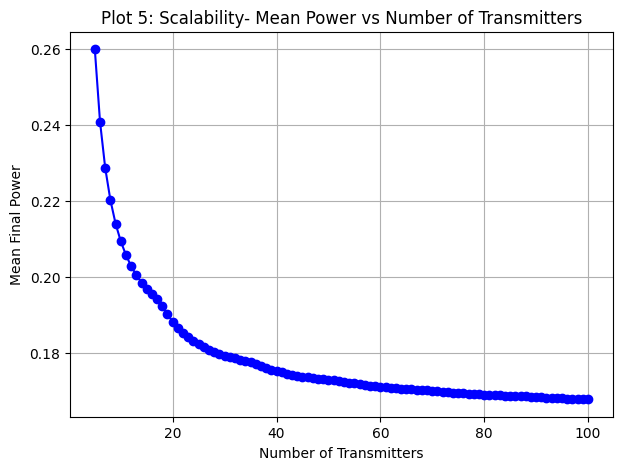

In [50]:
results = []

# Loop over number of transmitters
for i in range(5, 101):   # 1 to 100
    # Initialize inputs for n transmitters
    d_max = 300.0
    receiver_coordinates = (0.0, 0.0, 0.0)

    # Transmitters equally spaced along x-axis between 0 and 300 m
    x_positions = np.linspace(d_max/i, d_max, i)  # start after 0
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,i)]
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)              # current powers
    P_max = np.ones(i)                       # max power = 1
    eta = 1.0


    # Run your algorithm
    *_, df, _ = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_power = df['Final Power P*'].mean()

        # Save (n, mean_power) pair
        results.append((i, mean_power))

# Convert to DataFrame for plotting
scalability_df = pd.DataFrame(results, columns=['Users', 'Mean Power'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df['Users'], scalability_df['Mean Power'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Power")
plt.title("Plot 5: Scalability- Mean Power vs Number of Transmitters")
plt.grid(True)
plt.show()

###PLOT 6: Mean Utility vs Number of Users

Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing 

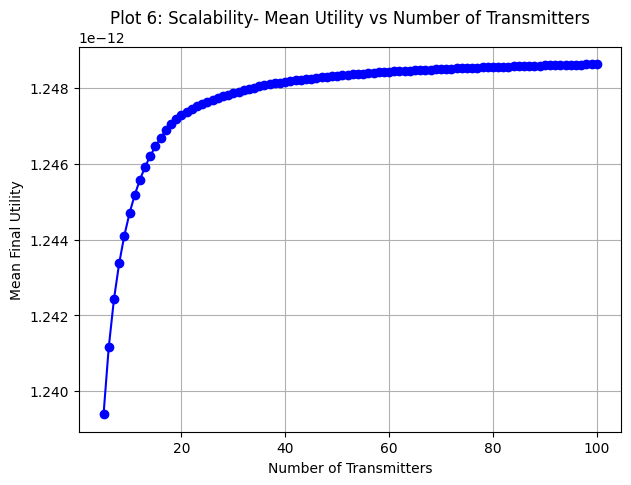

In [51]:
results = []

# Loop over number of transmitters
for i in range(5, 101):   # 1 to 100
    # Initialize inputs for n transmitters
    d_max = 300.0
    receiver_coordinates = (0.0, 0.0, 0.0)

    # Transmitters equally spaced along x-axis between 0 and 300 m
    x_positions = np.linspace(d_max/i, d_max, i)  # start after 0
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,i)]
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)              # current powers
    P_max = np.ones(i)                       # max power = 1
    eta = 1.0


    # Run your algorithm
    *_, df, _ = adaptive_best_response( h, eta, epsilon, P_max, max_iteration)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_utility = df['Final Utility'].mean()

        # Save (n, mean_power) pair
        results.append((i, mean_utility))


# Convert to DataFrame for plotting
scalability_df1 = pd.DataFrame(results, columns=['Users', 'Mean Utility'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df1['Users'], scalability_df1['Mean Utility'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Utility")
plt.title("Plot 6: Scalability- Mean Utility vs Number of Transmitters")
plt.grid(True)
plt.show()

###Complexity

Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response


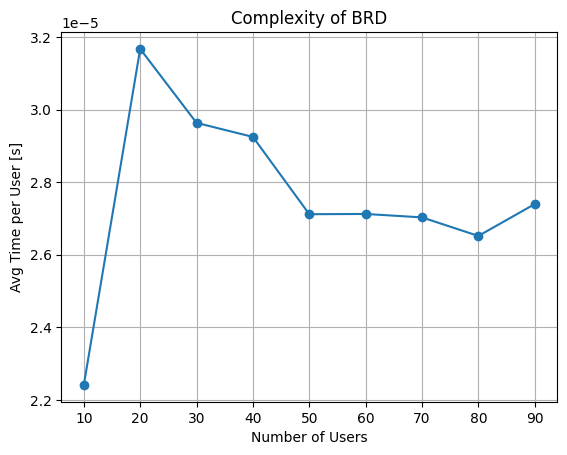

In [52]:
results = []

for i in range(10, 100, 10):  # test with 10,20,...,100 users
    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)
    d_max = 300.0
    receiver_coordinates = (0.0, 0.0, 0.0)

    # Transmitters equally spaced along x-axis between 0 and 300 m
    x_positions = np.linspace(d_max/i, d_max, i)  # start after 0
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(i)]
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    brd_result = adaptive_best_response(h, eta=1.0, epsilon=1e-3, P_max=P_max, max_iteration=100)

    if brd_result is not None:
        _, _, _, df, brd_time = brd_result
        if df is not None and brd_time is not None:
            avg_time_per_user = brd_time / i
            results.append((i, avg_time_per_user))

# Plot
if results:  # Only plot if there are results
    scalability_df = pd.DataFrame(results, columns=['Users', 'Avg BRD Time'])
    plt.plot(scalability_df['Users'], scalability_df['Avg BRD Time'], marker='o')
    plt.xlabel("Number of Users")
    plt.ylabel("Avg Time per User [s]")
    plt.title("Complexity of BRD")
    plt.grid(True)
    plt.show()
else:
    print("No data collected for plotting.")

Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing 

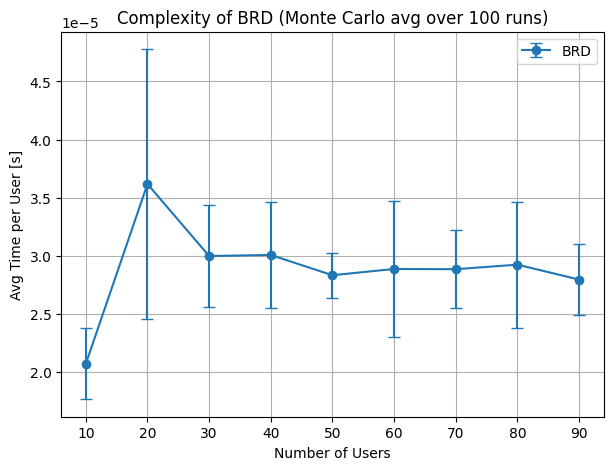

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Monte Carlo runs
MC_runs = 100 # you can try 1000 if time allows
results = []

for i in range(10, 100, 10):  # users = 5, 10, 15, ..., 100
    times = []
    for mc in range(MC_runs):
        P = np.random.uniform(0.1, 1.0, i)
        P_max = np.ones(i)
        d_max = 300.0
        receiver_coordinates = (0.0, 0.0, 0.0)

        # Transmitters equally spaced along x-axis between 0 and 300 m
        x_positions = np.linspace(d_max/i, d_max, i)
        transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

        # Channel gains
        h = [get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)
             for j in range(i)]

        # Run BRD
        _, _, _, df, brd_time = adaptive_best_response(
            h, eta=1.0, epsilon=1e-3, P_max=P_max, max_iteration=100
        )

        if brd_time is not None:
            avg_time_per_user = brd_time / i
            times.append(avg_time_per_user)

    # Store mean & std across Monte Carlo trials
    if times:
        mean_time = np.mean(times)
        std_time = np.std(times)
        results.append((i, mean_time, std_time))

# Convert to DataFrame
scalability_df = pd.DataFrame(results, columns=['Users', 'Avg BRD Time', 'Std'])

# Plot with error bars
plt.figure(figsize=(7,5))
plt.errorbar(
    scalability_df['Users'],
    scalability_df['Avg BRD Time'],
    yerr=scalability_df['Std'],
    fmt='-o',
    capsize=4,
    label="BRD"
)
plt.xlabel("Number of Users")
plt.ylabel("Avg Time per User [s]")
plt.title(f"Complexity of BRD (Monte Carlo avg over {MC_runs} runs)")
plt.grid(True)
plt.legend()
plt.show()


###Comparison Plots

In [54]:
from scipy.optimize import minimize

def centralized_solution(h, eta, c, P_max):
    n = len(h)

    # Objective: maximize sum of utilities
    def objective(P):
        return -np.sum(utility_vector(P, h, c, eta))  # negative for minimization

    # Bounds: 0 <= P_i <= P_max[i]
    bounds = [(0, P_max[i]) for i in range(n)]

    # Initial guess: half of max power
    P0 = np.array(P_max) / 2

    res = minimize(objective, P0, bounds=bounds, method="L-BFGS-B")

    return res.x  # optimal power allocation


Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response


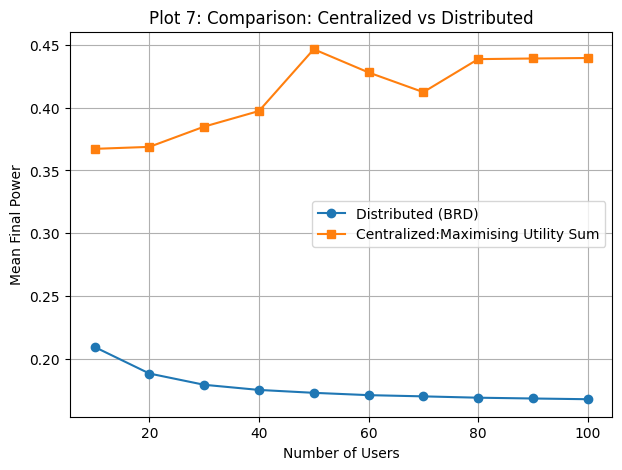

In [55]:
import matplotlib.pyplot as plt

brd_means = []
central_means = []
users_actual = [] # To store the actual number of users for which we have data

for n in range(10, 101, 10): # Iterate from 10 to 100 with step 10
    receiver_coordinates = (0.0, 0.0, 0.0)

    # Transmitters equally spaced along x-axis between 0 and 300 m
    x_positions = np.linspace(d_max/n, d_max, n)  # start after 0
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,n)]
    for j in range(0,n):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)
    P = np.random.uniform(0.1, 1.0, n)
    P_max = np.ones(n)
    eta = 1.0

    # --- Distributed (your BRD) ---
    c_star, _, _, df, _ = adaptive_best_response(h, eta, epsilon, P_max, max_iteration)
    if df is not None and c_star is not None: # Check if both df and c_star are not None
        brd_means.append(df['Final Power P*'].mean())

        # --- Centralized ---
        P_central = centralized_solution(h, eta, c_star, P_max)
        central_means.append(np.mean(P_central))
        users_actual.append(n) # Append the number of users for which we have data


# --- Plot comparison ---
plt.figure(figsize=(7,5))
# Use users_actual for the x-axis
plt.plot(users_actual, brd_means, marker='o', label="Distributed (BRD)")
plt.plot(users_actual, central_means, marker='s', label="Centralized:Maximising Utility Sum")
plt.xlabel("Number of Users")
plt.ylabel("Mean Final Power")
plt.title("Plot 7: Comparison: Centralized vs Distributed")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
import numpy as np

def mse_total(h, P, eta, include_sigma=False, sigma2=0.0):
    """
    Compute per-user MSE contributions and total MSE using:
        MSE_total = (  sum_n ( |h_n| * sqrt(P_n) * sqrt(eta) - 1 )^2 ) / N^2
    """
    h = np.asarray(h, dtype=float)
    P = np.asarray(P, dtype=float)
    if h.shape != P.shape:
        raise ValueError("h and P must have the same shape")

    N = h.size
    if N == 0:
        return np.array([]), 0.0

    # compute per-user squared error term (before 1/N^2 scaling)
    term = (np.abs(h) * np.sqrt(P) - 1.0)**2

    # per-user contribution as in the full formula (includes 1/N^2 factor)
    mse_per_user = term / (N**2)

    # total data-fit portion
    mse_data_fit = mse_per_user.sum()

    # optional noise term
    noise_term = 0.0
    if include_sigma:
        noise_term = (sigma2 / eta) / (N**2)

    mse_total = mse_data_fit + noise_term
    return float(mse_total)

In [57]:
import numpy as np

# show full precision
np.set_printoptions(precision=18, suppress=False, floatmode='maxprec', linewidth=200)

def as64(x):
    """Convert to float64 NumPy array without changing values."""
    return np.asarray(x, dtype=np.float64)

###(1/(MSExPxT)) efficiecy plot

Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
Executing adaptive best response
mse-min:  [0.09999999910808595  0.049999998045754335 0.03333333105986587  0.024999997654559424 0.019999996969963952 0.016666663006326143 0.014285710244361536 0.012499995960674228 0.011111107077812484
 0.009999995999018668]
mse-central:  [0.09999999999452137  0.04999999999718742  0.0333333333299865   0.024999999995981497 0.01999999997465566  0.016666666653900167 0.014285714278174008 0.012499999988046072 0.011111111099905214
 0.009999999989476184]
mse-brd-mse-min-arr:  [8.9142435100164619e-10 1.9539986156891231e-09 2.2733024698795568e-09 2.3453167047327028e-09 3.0299368777852997e-09 3.6602578641631300e-09 4.0412818699125941e-09 4.0392637446623469e-09
 4.0332434787

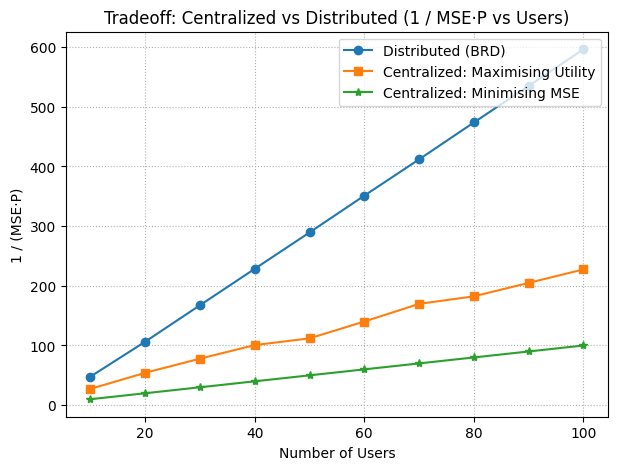

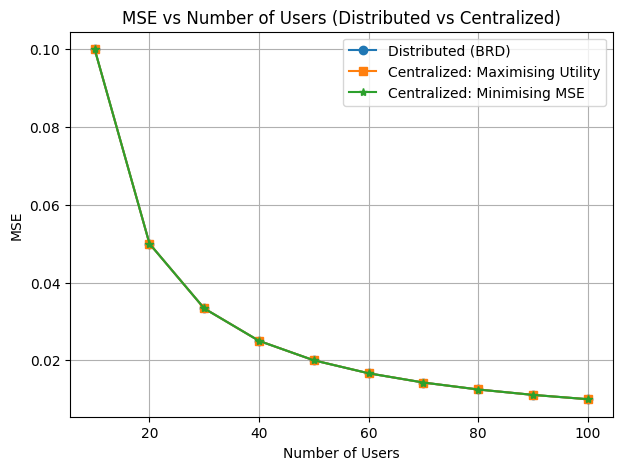

[0.0010559558868408203, 0.008970975875854492, 0.002507448196411133, 0.004403114318847656, 0.006269216537475586, 0.0032608509063720703, 0.0037059783935546875, 0.007732868194580078, 0.005117893218994141, 0.005599498748779297]
----------------------------------------------------------------------------------------------------------------------------------------------------------
[3.5666000258061104e-05, 5.4226000429480337e-05, 7.633499990333803e-05, 8.446300034847809e-05, 0.00012940400029037846, 7.695099975535413e-05, 8.860299931257032e-05, 0.0001677310001468868, 0.00010939599997072946, 0.00012052800047968049]


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import time  # (you had this already)

eta = 1.0

time_brd = []                 # avg time per user (BRD)
time_central = []             # avg time per user (Centralized)
time_mse = []

mse_brd = []                  # MSE with BRD power
mse_central = []              # MSE with centralized power
mse_min = []

power_brd_mean = []           # mean BRD power
power_central_mean = []       # mean centralized power
power_mse_min = []

users_actual = []             # x-axis
#r1 = []
#r2 = []





for i in range(10, 101, 10):  # 10,20,...,100 users
    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)
    d_max = 300.0
    receiver_coordinates = (0.0, 0.0, 0.0)

    # Transmitters equally spaced along x-axis between 0 and 300 m
    x_positions = np.linspace(d_max / i, d_max, i)  # start after 0
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = [get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)
         for j in range(i)]

    # --- Distributed (BRD) ---
    brd_result = adaptive_best_response(h, eta=eta, epsilon=1e-30, P_max=P_max, max_iteration=100)
    if brd_result is None:
        continue

    c_star, _, _, df, brd_time = brd_result
    if df is None or brd_time is None or c_star is None:
        continue
    #r1.append(brd_time)
    # timing (per user) for BRD
    time_brd.append(brd_time / i)

    # BRD power + MSE
    p_brd = df['Final Power P*'].values
    power_brd_mean.append(p_brd.mean())
    mse_brd.append(mse_total(h, p_brd, eta))

      # --- Centralized--min-mse --- ()
    """t_mse = time.perf_counter()
    # Convert h to a NumPy array before squaring
    h_array = np.array(h)
    p_mse_min = eta/(h_array**2)
    p_mse_min = np.clip(p_mse_min,0,1)
    cent_wall1 = time.perf_counter() - t_mse
    time_mse.append(cent_wall1 / i)

    power_mse_min.append(np.mean(p_mse_min))
    mse_min.append(mse_total(h, p_mse_min, eta))"""

    # --- Centralized — min-MSE (for loop, no NumPy array) ---
    t_mse = time.perf_counter()
    eps = 1e-30                      # avoid divide-by-zero
    p_mse_min_list = []

    for g in h:                      # h contains POWER gains g = |h|^2
        p = 1.0 / (max(pow(g,2), eps))  # P* = 1/(eta * g)
        p = min(max(p, 0.0), 1.0)      # clip to [0, P_max=1]
        p_mse_min_list.append(p)

    cent_wall1 = time.perf_counter() - t_mse
    #r2.append(cent_wall1)
    time_mse.append(cent_wall1 / i)

    # store stats
    p_mse_min = np.array(p_mse_min_list, dtype=float)
    power_mse_min.append(float(np.mean(p_mse_min)))
    mse_min.append(mse_total(h, p_mse_min, eta))


    # --- Centralized --- (measure its own time!)
    t0 = time.perf_counter()
    p_cent = centralized_solution(h, eta, c_star, P_max)
    cent_wall = time.perf_counter() - t0
    time_central.append(cent_wall / i)

    power_central_mean.append(np.mean(p_cent))
    mse_central.append(mse_total(h, p_cent, eta))

    users_actual.append(i)

# ---- Make arrays of equal length (defensive) ----
min_len = min(len(users_actual), len(mse_brd), len(mse_central),
              len(power_brd_mean), len(power_central_mean),
              len(time_brd), len(time_central))

users_x         = np.array(users_actual[:min_len])


mse_brd_arr     = as64(mse_brd[:min_len])
mse_central_arr = as64(mse_central[:min_len])
mse_min_arr     = as64(mse_min[:min_len])

"""
mse_brd_arr     = np.array(mse_brd[:min_len])
mse_central_arr = np.array(mse_central[:min_len])
mse_min_arr = np.array(mse_min[:min_len])"""

p_brd_mean_arr  = np.array(power_brd_mean[:min_len])
p_cent_mean_arr = np.array(power_central_mean[:min_len])
p_mse_min_arr = np.array(power_mse_min[:min_len])

t_brd_arr       = np.array(time_brd[:min_len])
t_cent_arr      = np.array(time_central[:min_len])
t_mse_min_arr = np.array(time_mse[:min_len])



# Tradeoff metrics (use each method's own time)
metric_brd      = mse_brd    * p_brd_mean_arr # * t_brd_arr
metric_central  = mse_central * p_cent_mean_arr #* t_cent_arr
metric_mse_min = mse_min * p_mse_min_arr #* t_mse_min_arr

print("mse-min: ",mse_min_arr)
print("mse-central: ",mse_central_arr)
print("mse-brd-mse-min-arr: ",mse_brd_arr-mse_min_arr)

# ================== PLOT 1: tradeoff with inset zoom on Centralized ==================
fig, ax = plt.subplots(figsize=(7,5))

# guard against divide-by-zero to avoid inf
y_brd  = 1.0 / np.clip(metric_brd,     1e-30, None)
y_cent = 1.0 / np.clip(metric_central, 1e-30, None)
y_min_mse = 1.0/np.clip(metric_mse_min , 1e-30, None)

ax.plot(users_x, y_brd,  label="Distributed (BRD)", marker="o")
ax.plot(users_x, y_cent, label="Centralized: Maximising Utility",       marker="s")
ax.plot(users_x, y_min_mse, label="Centralized: Minimising MSE",       marker="*")
ax.set_xlabel("Number of Users")
ax.set_ylabel("1 / (MSE·P)")
ax.set_title("Tradeoff: Centralized vs Distributed (1 / MSE·P vs Users)")
ax.grid(True, ls=":")
ax.legend(loc="upper right")

"""
# ---- Inset: TOP-LEFT, nudged inward; ticks on the RIGHT so they don't overlap ----
axins = inset_axes(
    ax,
    width="36%", height="36%",       # percent of the bbox below
    loc="upper left",
    bbox_to_anchor=(0.14, 0.06, 0.86, 0.92),  # (x0, y0, w, h) in axes coords
    bbox_transform=ax.transAxes,
    borderpad=0.0
)

axins.plot(users_x, y_cent, marker="s", color="tab:orange")
axins.set_xlim(users_x.min()-1, users_x.max()+1)
axins.set_ylim(0, y_cent.max()*1.15)
axins.set_title("Centralized (zoom)", fontsize=8)
axins.grid(True, ls=":")
axins.yaxis.tick_right()
axins.yaxis.set_label_position("right")
axins.tick_params(axis="both", labelsize=8)
axins.set_facecolor((1, 1, 1, 0.9))  # subtle white background

plt.subplots_adjust(left=0.12)  # a little extra left margin for main y-ticks
plt.tight_layout()
plt.show()"""

# ================== PLOT 2: MSE vs users (unchanged) ==================
plt.figure(figsize=(7,5))
plt.plot(users_x, mse_brd_arr,     label="Distributed (BRD)", marker="o")
plt.plot(users_x, mse_central_arr, label="Centralized: Maximising Utility",       marker="s")
plt.plot(users_x, mse_min_arr, label="Centralized: Minimising MSE",       marker="*")
plt.xlabel("Number of Users")
plt.ylabel("MSE")
plt.title("MSE vs Number of Users (Distributed vs Centralized)")
plt.legend()
plt.grid(True)
plt.show()



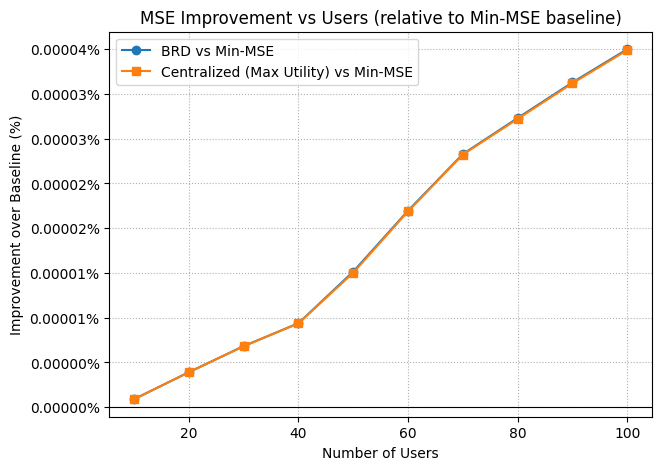

Users          : [ 10  20  30  40  50  60  70  80  90 100]
BRD improvement: [1.0e-06 4.0e-06 7.0e-06 9.0e-06 1.5e-05 2.2e-05 2.8e-05 3.2e-05 3.6e-05 4.0e-05]
CENT improvement: [1.0e-06 4.0e-06 7.0e-06 9.0e-06 1.5e-05 2.2e-05 2.8e-05 3.2e-05 3.6e-05 4.0e-05]


In [59]:
# --- % improvement over the baseline (Min-MSE) ---
import numpy as np
import matplotlib.ticker as mticker

eps = 1e-30  # guard against divide-by-zero
base = np.clip(mse_min_arr, eps, None)

impr_brd  = (mse_brd_arr- base)     / base * 100.0   # BRD vs baseline
impr_cent = (mse_central_arr -base) / base * 100.0   # Centralized (max utility) vs baseline

# Plot: % improvement vs number of users
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(users_x, impr_brd,  marker="o", label="BRD vs Min-MSE")
ax.plot(users_x, impr_cent, marker="s", label="Centralized (Max Utility) vs Min-MSE")
ax.axhline(0, color="k", lw=0.8)  # baseline reference

ax.set_xlabel("Number of Users")
ax.set_ylabel("Improvement over Baseline (%)")
ax.set_title("MSE Improvement vs Users (relative to Min-MSE baseline)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))  # show % ticks nicely
ax.grid(True, ls=":")
ax.legend()
plt.show()

# (optional) print the values
print("Users          :", users_x)
print("BRD improvement:", np.round(impr_brd, 6))
print("CENT improvement:", np.round(impr_cent, 6))

In [66]:
import numpy as np
import pandas as pd

# high-precision display (optional)
np.set_printoptions(precision=18, suppress=False, floatmode='maxprec', linewidth=200)
pd.set_option('display.float_format', lambda v: f"{v:.12e}")

# ---- Table 1: % improvement over Min-MSE baseline ----
eps  = 1e-300
base = np.clip(mse_min_arr, eps, None)

df_impr = pd.DataFrame({
    "Users": users_x.astype(int),
    "BRD vs Min-MSE (%)":        (mse_brd_arr - base)     / base * 100.0,
    "Central vs Min-MSE (%)":    (mse_central_arr - base) / base * 100.0,
})

print("\nPercentage Improvement over Min-MSE baseline")
print(df_impr.to_string(
    index=False,
    col_space={"Users": 8, "BRD vs Min-MSE (%)": 22, "Central vs Min-MSE (%)": 24},
    formatters={
        "BRD vs Min-MSE (%)":     lambda v: f"{v:.6f}",
        "Central vs Min-MSE (%)": lambda v: f"{v:.6f}",
    },
))

# ---- Table 2: Actual MSE values (stacked) with extra spacing ----
df_actual = pd.concat([
    pd.DataFrame({"Method": "Distributed (BRD)",         "Users": users_x.astype(int), "MSE": mse_brd_arr}),
    pd.DataFrame({"Method": "Centralized (Max Utility)", "Users": users_x.astype(int), "MSE": mse_central_arr}),
    pd.DataFrame({"Method": "Min-MSE Baseline",          "Users": users_x.astype(int), "MSE": mse_min_arr}),
], ignore_index=True)

order = ["Distributed (BRD)", "Centralized (Max Utility)", "Min-MSE Baseline"]
df_actual["Method"] = pd.Categorical(df_actual["Method"], categories=order, ordered=True)
df_actual = df_actual.sort_values(["Method", "Users"]).reset_index(drop=True)

print("\nActual MSE values (stacked)")
print(df_actual.to_string(
    index=False,
    col_space={"Method": 28, "Users": 10, "MSE": 24},
    formatters={"MSE": lambda v: f"{v:.12e}"},
))




Percentage Improvement over Min-MSE baseline
   Users     BRD vs Min-MSE (%)   Central vs Min-MSE (%)
      10               0.000001                 0.000001
      20               0.000004                 0.000004
      30               0.000007                 0.000007
      40               0.000009                 0.000009
      50               0.000015                 0.000015
      60               0.000022                 0.000022
      70               0.000028                 0.000028
      80               0.000032                 0.000032
      90               0.000036                 0.000036
     100               0.000040                 0.000040

Actual MSE values (stacked)
                      Method      Users                      MSE
           Distributed (BRD)         10       9.999999999951e-02
           Distributed (BRD)         20       4.999999999975e-02
           Distributed (BRD)         30       3.333333333317e-02
           Distributed (BRD)         4

In [61]:
import numpy as np
import math

N = 10
max_iteration = 50
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

#h contains channel gains for both the 5 nodes
h_outdoor = [0 for i in range(N)]
for i in range(N):
    h_outdoor[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

h_indoor = [0 for i in range(N)]
for i in range(N):
    h_indoor[i] = get_channel_gain_InH(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)              # current powers
P_max = np.ones(N)                       # max power = 1 for all
eta = 1.0

epsilon = np.float64(1e-70)
c_star, utility_histories, power_histories, df_outdoor,brd_time = adaptive_best_response(
        h_outdoor, eta, epsilon, P_max, max_iteration
    )

c_star, utility_histories, power_histories, df_indoor,brd_time = adaptive_best_response(
        h_indoor, eta, epsilon, P_max, max_iteration
    )

Executing adaptive best response
Executing adaptive best response


###Indoor/Outdoor Comparison

10
10


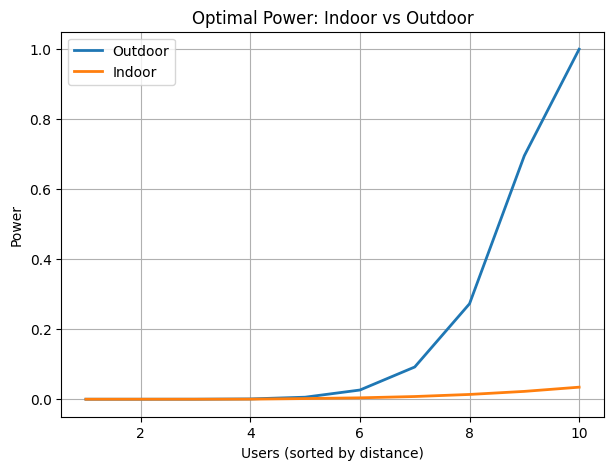

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Example arrays (replace these with your real values)
# sorted over the same set of users/distances
power_indoor = df_indoor['Final Power P*']   # your computed indoor power values
print(len(power_indoor))
power_outdoor = df_outdoor['Final Power P*']  # your computed outdoor power values
print(len(power_outdoor))

users = np.arange(1, len(power_indoor)+1)  # x-axis: user index (sorted)

plt.figure(figsize=(7,5))
plt.plot(users, power_outdoor, label="Outdoor", linewidth=2)
plt.plot(users, power_indoor, label="Indoor", linewidth=2)
plt.xlabel("Users (sorted by distance)")
plt.ylabel("Power")
plt.title("Optimal Power: Indoor vs Outdoor")
plt.grid(True)
plt.legend()
plt.show()